# Introduction to Video Models with Hugging Face 🤗

This notebook focuses on image workflows with the `diffusers` library. We start with image loading and color-channel inspection, then move into diffusion-based image generation with DDPM.

### Key Concepts Covered:
1.  **Image Inspection**: Loading images with PIL, NumPy, OpenCV, and Matplotlib.
2.  **Color Channels**: Exploring RGB components and grayscale conversion.
3.  **Diffusion Models**: Using `DDPMPipeline`, `DDPMScheduler`, and `UNet2DModel`.
4.  **Manual Sampling**: Stepping through a denoising loop to understand reverse diffusion.

---

## Environment Setup
Before starting, ensure you have the necessary environment and dependencies:
- **Environment**: `conda activate hugvenv312`
- **Installation**: `pip install -r requirements.txt`

### Useful Resources
- [Hugging Face Diffusers Documentation](https://huggingface.co/docs/diffusers/index): Official documentation for the `diffusers` library.
- [Hugging Face Model Hub](https://huggingface.co/models): Browse pretrained image and diffusion models.
- [PyTorch Documentation](https://pytorch.org/docs/stable/index.html): Reference for tensors, modules, and GPU execution.

In [43]:
import warnings

# Silence warnings so the notebook output stays focused on the examples.
warnings.filterwarnings("ignore")

print("Jupyter Notebook Initialized")

Jupyter Notebook Initialized


In [44]:
# Capture the runtime details so we know which image-processing paths are available.
import platform
import torch
import torch.nn.functional as F
import subprocess

print(f"--- System Information ---")
print(f"Platform: {platform.platform()}")
print(f"Python:   {platform.python_version()}")
print(f"PyTorch:  {torch.__version__}")

print(f"\n--- GPU/ROCm Accelerators ---")
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    print(f"Device Count:   {torch.cuda.device_count()}")
    print(f"Primary Device: {torch.cuda.get_device_name(0)}")
else:
    print("Optimization Note: No CUDA-capable GPU detected. Operations will run on CPU.")

--- System Information ---
Platform: Windows-11-10.0.26200-SP0
Python:   3.12.13
PyTorch:  2.9.1+rocm7.2.1

--- GPU/ROCm Accelerators ---
CUDA Available: True
Device Count:   1
Primary Device: AMD Radeon RX 7900 XT


### Video models

In [45]:
import torch
import diffusers
import transformers
import cv2
from diffusers import StableVideoDiffusionPipeline

### Generating Video using Diffusion

In [46]:
# Load the Stable Video Diffusion model from Hugging Face's model hub. The model is loaded with half-precision (float16) for improved performance on compatible GPUs.
pipeline = StableVideoDiffusionPipeline.from_pretrained(
    "stabilityai/stable-video-diffusion-img2vid-xt", 
    torch_dtype=torch.float16, 
    variant="fp16"
)

Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00, 10.90it/s]


In [47]:
pipeline

StableVideoDiffusionPipeline {
  "_class_name": "StableVideoDiffusionPipeline",
  "_diffusers_version": "0.38.0",
  "_name_or_path": "stabilityai/stable-video-diffusion-img2vid-xt",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    "transformers",
    "CLIPVisionModelWithProjection"
  ],
  "scheduler": [
    "diffusers",
    "EulerDiscreteScheduler"
  ],
  "unet": [
    "diffusers",
    "UNetSpatioTemporalConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKLTemporalDecoder"
  ]
}

In [48]:
path = "image.png"
path

'image.png'

In [49]:
from diffusers.utils import load_image, export_to_video

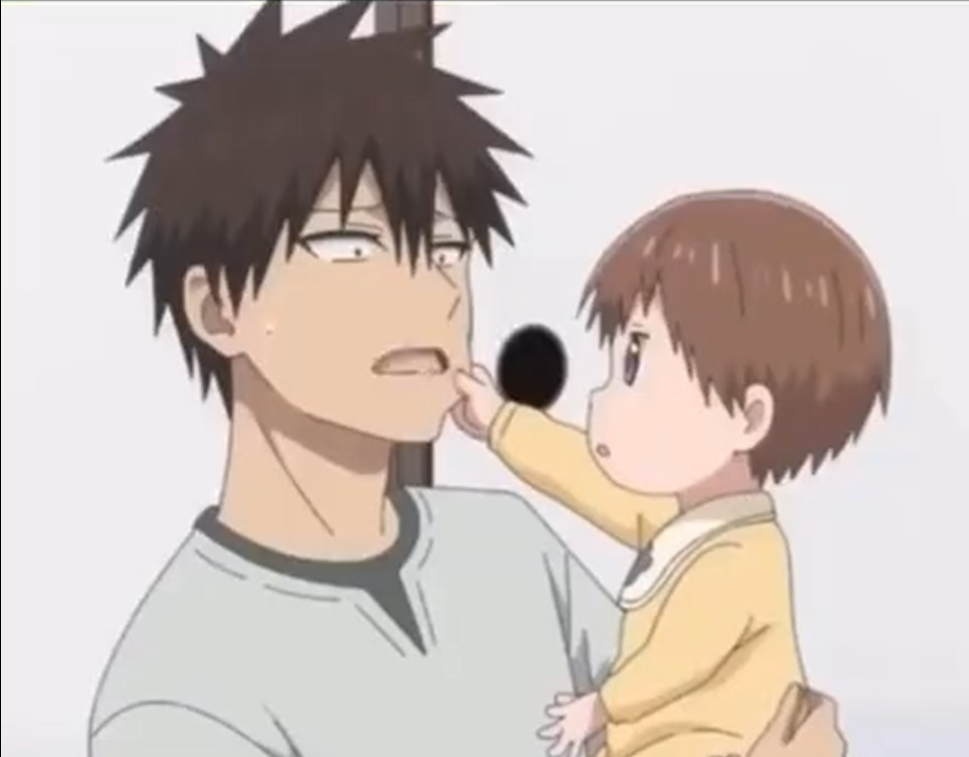

In [50]:
image = load_image(path)
image

In [51]:
pipeline.enable_model_cpu_offload()

In [52]:
generator = torch.manual_seed(42)  # Set a manual seed for reproducibility

generator

In [ ]:
frames = pipeline(image=image, decode_chunk_size=8, generator=generator).frames[0]

100%|██████████| 25/25 [20:19<00:00, 48.77s/it]   


In [ ]:
frames[2]

In [ ]:
export_to_video(frames, "output_video.mp4", fps=7) # Export the generated frames to a video file named "output_video.mp4" with a frame rate of 7 frames per second.

### Using HuggingFace model to generate video using Image & Prompt

In [ ]:
import torch
torch.cuda.empty_cache()  # Clear the GPU memory cache to free up resources after video generation.

from diffusers import I2VGenXLPipeline
from diffusers.utils import load_image, export_to_video

repo_id = "ali-vilab/i2v-gen-xl"

In [ ]:
pipeline = I2VGenXLPipeline.from_pretrained(repo_id, dtype=torch.bfloat16, device_map="cuda")
pipeline.to("cuda")

prompt = "A man with short gray hair plays a red electric guitar."
image = load_image(
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/guitar-man.png"
)

output = pipeline(image=image, prompt=prompt).frames[0]
export_to_video(output, "output.mp4")